# 13 — Clustering

**Course:** Introduction to Data Science (BS Data Science, 3rd semester)
**CLO:** CLO-2 — Apply basic machine learning techniques.

Clustering finds groups **without labels** — nobody told the algorithm the
answer; it discovers structure from the data alone. This is how market
segmentation, anomaly detection, and customer grouping work. The price of no
labels: no accuracy score — you must validate clusters with plots and domain
sense.

---


## Learning objectives

By the end of this notebook you will be able to:

1. Explain unsupervised learning and how k-means works.
2. Fit `KMeans` and read `labels_` and `cluster_centers_`.
3. Choose k with the elbow method.
4. Scale features before clustering — and explain why.
5. Validate clusters against known labels with `crosstab`.

---


## Theory: how k-means works

Four steps, repeated until stable:

1. Pick k and place k initial centers.
2. **Assign** every point to its nearest center.
3. **Update** each center to the mean of its assigned points.
4. Repeat steps 2–3 until assignments stop changing.

The name makes sense now: the *mean* of a group becomes the new center, for
*k* groups. Because distance drives the assignment, **feature scale matters**
— a column in millions silently dominates a column in units. Standardize
first (z-scores — notebook 02's skill).

---


labels (first 5): [0 0 0 0 0]
centers:
 [[-0.0462257   0.01360893]
 [ 4.05129949  4.01739506]]
inertia (total distance to centers): 58.38


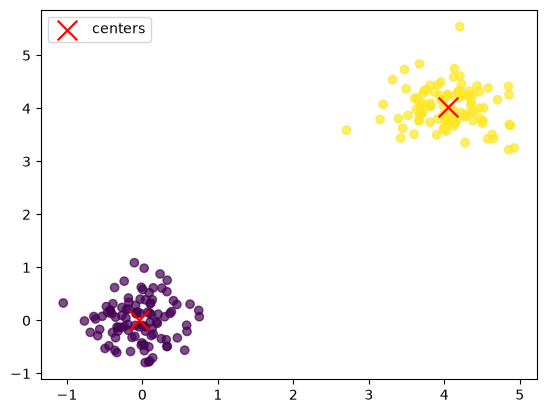

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Two obvious blobs + reproducible randomness
np.random.seed(42)
blob_a = np.random.normal([0, 0], 0.4, (100, 2))
blob_b = np.random.normal([4, 4], 0.4, (100, 2))
X = np.vstack([blob_a, blob_b])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)

print("labels (first 5):", kmeans.labels_[:5])
print("centers:\n", kmeans.cluster_centers_)
print("inertia (total distance to centers):", round(kmeans.inertia_, 2))

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="x", s=200, color="red", label="centers")
plt.legend()
plt.show()


## Choosing k: the elbow method

`inertia` = total squared distance of points to their centers. More clusters
always lower inertia — so you look for the **bend**: before the elbow each
new cluster buys a big drop (real structure); after it, you're splitting
noise. Elbows are often rounded — treat k as a recommendation, then inspect
the actual clusters.

---


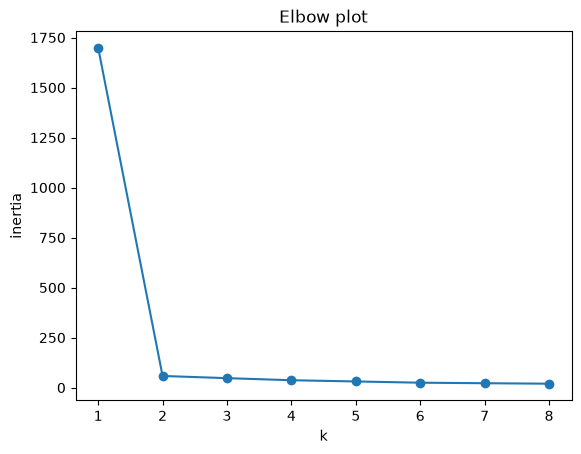

In [2]:
inertias = []
ks = range(1, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow plot")
plt.show()


## Scaling matters: the demonstration

Cluster the penguins measurements **with** and **without** scaling. Body
mass is in grams; bill length in millimeters — without scaling, k-means
essentially clusters on body mass alone.

---


In [3]:
penguins = sns.load_dataset("penguins").dropna()
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
Xp = penguins[features]

# Unscaled
km_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xp)
# Scaled
Xp_scaled = StandardScaler().fit_transform(Xp)
km_scaled = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xp_scaled)

penguins["cluster_raw"] = km_raw.labels_
penguins["cluster_scaled"] = km_scaled.labels_

print("UNSCALED vs species:")
print(pd.crosstab(penguins["cluster_raw"], penguins["species"]))
print()
print("SCALED vs species:")
print(pd.crosstab(penguins["cluster_scaled"], penguins["species"]))


UNSCALED vs species:
species      Adelie  Chinstrap  Gentoo
cluster_raw                           
0                38         16      48
1               108         52       1
2                 0          0      70

SCALED vs species:
species         Adelie  Chinstrap  Gentoo
cluster_scaled                           
0                  124          5       0
1                    0          0     119
2                   22         63       0


## Beginner example: six points, two clusters

---


In [4]:
X6 = np.array([[1, 1], [1, 2], [2, 1],      # group 1
               [10, 10], [11, 10], [10, 11]])  # group 2

km = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X6)
print("labels:", km.labels_)
print("centers:\n", km.cluster_centers_)

# Expected output:
#   labels: [0 0 0 1 1 1]
#   centers:
#    [[ 1.33333333  1.33333333]
#     [10.33333333 10.33333333]]


labels: [1 1 1 0 0 0]
centers:
 [[10.33333333 10.33333333]
 [ 1.33333333  1.33333333]]


## Intermediate example: segments, validated

Cluster customers, then validate: does the unsupervised grouping line up with
a known label? `crosstab` reveals the match — and the confusion.

---


species  Adelie  Chinstrap  Gentoo
segment                           
0           124          5       0
1             0          0     119
2            22         63       0

         body_mass_g  bill_length_mm
segment                             
0             3594.0            38.0
1             5092.0            48.0
2             3898.0            48.0


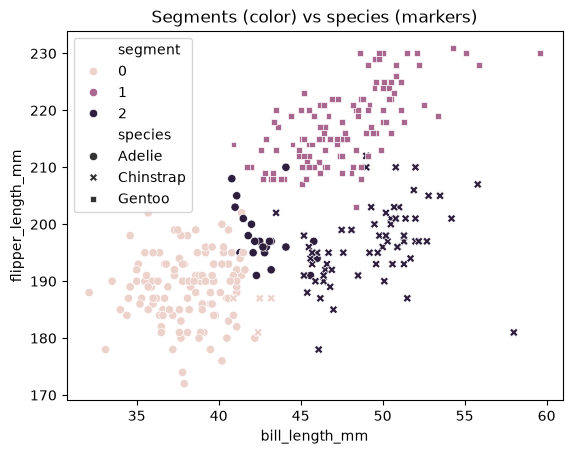

In [5]:
# Real-ish task: segment penguins by measurements, then compare to species
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xp_scaled)
penguins["segment"] = km.labels_

print(pd.crosstab(penguins["segment"], penguins["species"]))
print()
# Which segment is heaviest on average? Interpretable segments!
print(penguins.groupby("segment")[["body_mass_g", "bill_length_mm"]].mean().round(0))

sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="segment", style="species")
plt.title("Segments (color) vs species (markers)")
plt.show()


## Exercises

---


### Exercise 1 — Elbow

Build an elbow plot for the **scaled** penguins features (k from 1 to 7).
Where is the bend? (Answer: around k=3 — matching the three species.)

In [6]:
# your code here


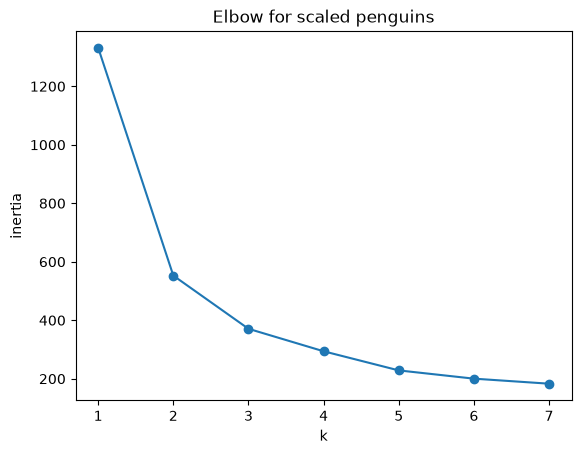

In [7]:
# Solution
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xp_scaled)
    inertias.append(km.inertia_)
plt.plot(range(1, 8), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow for scaled penguins")
plt.show()


### Exercise 2 — Scale experiment

Cluster the unscaled penguins features with k=3 and compare the crosstab
against species with the scaled version. Which is more species-aligned, and
why?

In [8]:
# your code here


In [9]:
# Solution
km_u = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xp)
table_u = pd.crosstab(km_u.labels_, penguins["species"])
table_s = pd.crosstab(km_scaled.labels_, penguins["species"])
print("unscaled — diagonal share:",
      round(sum(np.max(table_u, axis=1)) / table_u.values.sum(), 2))
print("scaled   — diagonal share:",
      round(sum(np.max(table_s, axis=1)) / table_s.values.sum(), 2))


unscaled — diagonal share: 0.68
scaled   — diagonal share: 0.92


### Exercise 3 — Cluster the tips

Cluster the tips dataset on `total_bill` and `tip` (scaled), k=2. What does
each segment look like in terms of average bill and tip? Write one sentence
describing the segments.

In [10]:
import seaborn as sns
tips = sns.load_dataset("tips")

# your code here


In [11]:
# Solution
X_tips = StandardScaler().fit_transform(tips[["total_bill", "tip"]])
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_tips)
tips["segment"] = km.labels_
print(tips.groupby("segment")[["total_bill", "tip"]].mean().round(2))


         total_bill   tip
segment                  
0             30.96  4.62
1             15.81  2.42


## Challenge exercise

Create your own dataset with `make_blobs` (from `sklearn.datasets`) — e.g.,
4 well-separated blobs with `cluster_std=0.8`, 300 samples, seed 42.

1. Find k with the elbow method — does the plot clearly suggest 4?
2. Fit k-means with the suggested k; plot the points colored by cluster
   with the centers marked.
3. Now run k-means on **random noise** (`np.random.normal`, 300 points).
   What does the elbow look like — and what does that tell you about why we
   never trust k-means blindly?

In [12]:
from sklearn.datasets import make_blobs

# your code here


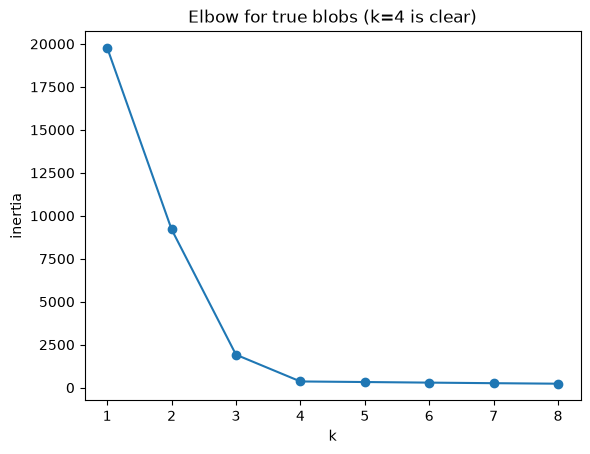

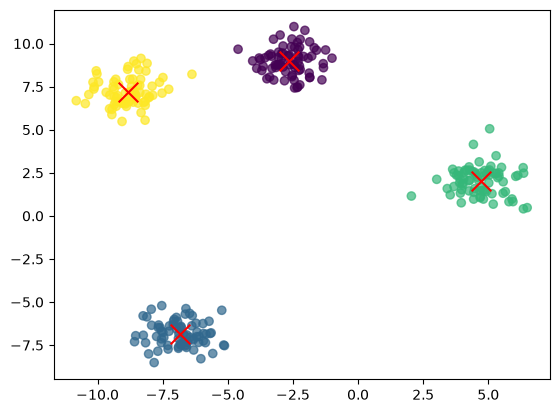

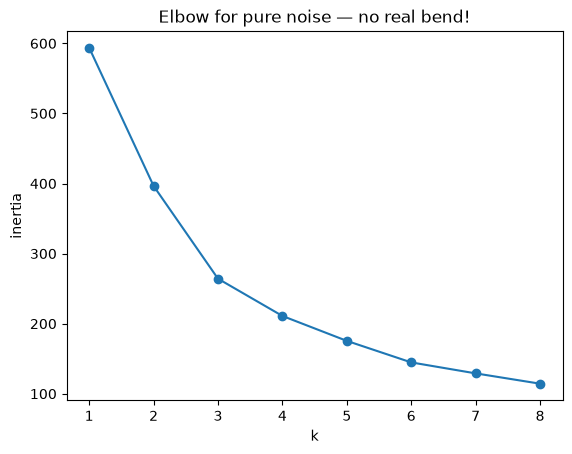

In [13]:
# Solution
from sklearn.datasets import make_blobs

Xb, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xb).inertia_
            for k in range(1, 9)]
plt.plot(range(1, 9), inertias, "o-")
plt.title("Elbow for true blobs (k=4 is clear)"); plt.xlabel("k"); plt.ylabel("inertia")
plt.show()

km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xb)
plt.scatter(Xb[:, 0], Xb[:, 1], c=km.labels_, cmap="viridis", alpha=0.7)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker="x", s=200, color="red")
plt.show()

# Noise check: k-means always "finds" clusters even in noise
rng = np.random.default_rng(0)
Xnoise = rng.normal(size=(300, 2))
inertias_noise = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xnoise).inertia_
                  for k in range(1, 9)]
plt.plot(range(1, 9), inertias_noise, "o-")
plt.title("Elbow for pure noise — no real bend!"); plt.xlabel("k"); plt.ylabel("inertia")
plt.show()


## Recap

- Unsupervised: no labels; k-means finds k groups by nearest-center assignment.
- Algorithm: assign → update centers → repeat.
- `inertia` drives the **elbow plot** — choose k at the bend.
- **Scale features** before clustering (distance-based).
- Validate with `crosstab` against known labels when available.
- k-means always finds clusters — even in noise. Plot and think before believing.

---


## Questions

1. What is the difference between supervised and unsupervised learning?
2. Describe k-means in four steps.
3. Why does inertia always decrease as k grows?
4. Why must features be scaled before k-means?
5. How do you check whether clusters are meaningful when you have labels?
6. True/False: k-means can find clusters in pure noise. (True — that's why validation matters.)

---
**Next:** notebook 14 — PandasAI.
